# 04 - Random Forest

**Inputs:** preprocessed splits produced by `00_eda_and_preprocessing.ipynb`
(`artifacts/splits/splits.npz`). Do not re-split or re-scale here.

**Outputs:** `artifacts/results/random_forest.json`,
`artifacts/models/random_forest.joblib`,
plus ROC / PR / confusion-matrix PNGs in `figures/`.

**Why this model**

Random Forest is our **bagging ensemble**: many de-correlated decision trees vote. It handles nonlinear feature interactions and is much harder to overfit than a single tree. We expect it to be competitive with XGBoost on F1 and to give clean permutation feature importances for the report's interpretation section. The search space is large (n_estimators up to 500), so we use **RandomizedSearchCV** with 20 iterations instead of full grid.

The structure below is identical across the five model notebooks:
1. Load shared splits.
2. **Variant A** — model with built-in imbalance handling (`class_weight`, `scale_pos_weight`, or distance weighting).
3. **Variant B** — SMOTE oversampling on training folds only (via `imblearn.pipeline.Pipeline`).
4. Pick the variant with the higher CV F1, refit, evaluate on the held-out test set.
5. Save the result JSON + the fitted model.


## 1. Setup & load shared splits

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocess import load_splits
from src.tuning import grid_search, random_search, CV
from src.evaluation import (
    evaluate, save_results, print_metric_table,
    plot_confusion, plot_roc, plot_pr, _scores,
)

SPLITS_DIR  = PROJECT_ROOT / "artifacts" / "splits"
MODELS_DIR  = PROJECT_ROOT / "artifacts" / "models"
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "results"
FIG_DIR     = PROJECT_ROOT / "figures"
for d in (MODELS_DIR, RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

data = load_splits(SPLITS_DIR)
X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
feature_names   = data["feature_names"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"train fraud rate: {y_train.mean():.4f}, test fraud rate: {y_test.mean():.4f}")


X_train: (7430, 45), X_test: (1858, 45)
train fraud rate: 0.1783, test fraud rate: 0.1781


## 2. ### Variant A: `class_weight='balanced'`

In [2]:
from sklearn.ensemble import RandomForestClassifier

estimator_cw = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

dist_cw = {
    "n_estimators":     [200, 500],
    "max_depth":        [None, 10, 20],
    "max_features":     ["sqrt", "log2"],
    "min_samples_leaf": [1, 5],
}

search_cw = random_search(estimator_cw, dist_cw, n_iter=20)
search_cw.fit(X_train, y_train)
print(f"Variant A best CV F1: {search_cw.best_score_:.4f}  params: {search_cw.best_params_}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


Variant A best CV F1: 0.8720  params: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None}


## 3. ### Variant B: SMOTE oversampling

In [3]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pipe_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf",   RandomForestClassifier(random_state=42, n_jobs=-1)),
])

dist_smote = {
    "clf__n_estimators":     [200, 500],
    "clf__max_depth":        [None, 10, 20],
    "clf__max_features":     ["sqrt", "log2"],
    "clf__min_samples_leaf": [1, 5],
}

search_smote = random_search(pipe_smote, dist_smote, n_iter=20)
search_smote.fit(X_train, y_train)
print(f"Variant B best CV F1: {search_smote.best_score_:.4f}  params: {search_smote.best_params_}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/pyth

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


...

/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/akash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Variant B best CV F1: 0.8809  params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20}


## 4. Pick the better variant, refit & evaluate on test

In [4]:
# Pick the variant with the better CV F1 score
variants = {
    "class_weight": search_cw,
    "smote":        search_smote,
}
best_variant = max(variants, key=lambda k: variants[k].best_score_)
best_search  = variants[best_variant]
best_model   = best_search.best_estimator_

print(f"\nWinning variant: {best_variant}")
print(f"  CV F1 (winning):       {best_search.best_score_:.4f}")
print(f"  CV F1 (other variant): {variants['smote' if best_variant=='class_weight' else 'class_weight'].best_score_:.4f}")
print(f"  Best params:           {best_search.best_params_}")

# Final evaluation on the held-out test set
results = evaluate(
    best_model,
    X_train, y_train, X_test, y_test,
    model_name="random_forest",
    best_params=best_search.best_params_,
    imbalance_strategy=best_variant,
)
print_metric_table(results)

save_results(results, RESULTS_DIR / "random_forest.json")
joblib.dump(best_model, MODELS_DIR / "random_forest.joblib")
print(f"\nSaved -> artifacts/results/random_forest.json + artifacts/models/random_forest.joblib")



Winning variant: smote
  CV F1 (winning):       0.8809
  CV F1 (other variant): 0.8720
  Best params:           {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20}

=== random_forest (smote) ===
Best params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20}
metric                   train      test
accuracy                1.0000    0.9564
balanced_accuracy       1.0000    0.9131
precision               1.0000    0.9032
recall                  1.0000    0.8459
f1                      1.0000    0.8736
roc_auc                 1.0000    0.9851
pr_auc                  1.0000    0.9486
Confusion matrix (test):
[[1497   30]
 [  51  280]]

Saved -> artifacts/results/random_forest.json + artifacts/models/random_forest.joblib


## 5. Diagnostic plots

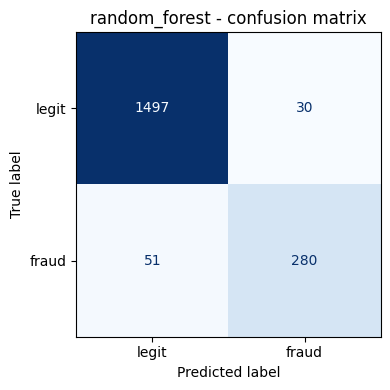

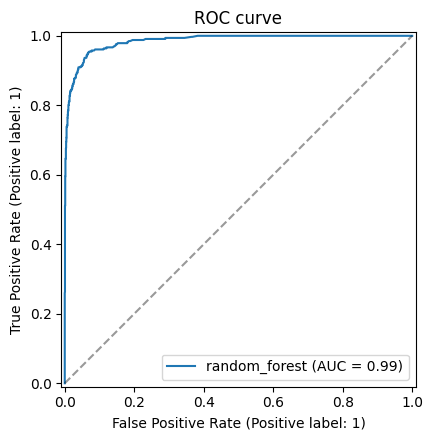

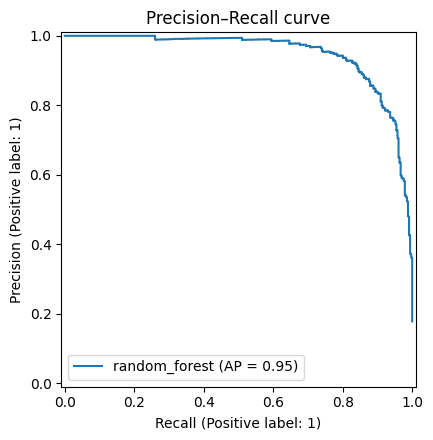

In [5]:
# Diagnostic plots
y_pred = best_model.predict(X_test)
y_score = _scores(best_model, X_test)

fig_cm = plot_confusion(y_test, y_pred, title=f"{results['model_name']} - confusion matrix")
fig_cm.savefig(FIG_DIR / "random_forest_confusion.png", bbox_inches="tight")
plt.show()

if y_score is not None:
    fig_roc = plot_roc(y_test, y_score, label="random_forest")
    fig_roc.savefig(FIG_DIR / "random_forest_roc.png", bbox_inches="tight")
    plt.show()

    fig_pr = plot_pr(y_test, y_score, label="random_forest")
    fig_pr.savefig(FIG_DIR / "random_forest_pr.png", bbox_inches="tight")
    plt.show()


## 6. Hand-off to the comparison notebook

`artifacts/results/random_forest.json` now contains:

```
model_name, imbalance_strategy, best_params,
train: {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
test:  {accuracy, balanced_accuracy, precision, recall, f1, roc_auc, pr_auc},
confusion_matrix_test
```

`06_comparison_and_interpretation.ipynb` will read this file (alongside the
other four) to build the comparison table and overlay the ROC / PR curves.